# Importing Necessary Libraries

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading dataset

In [99]:
data = pd.read_excel("Mall_Customers.xlsx")

# Data Preprocessing

In [100]:
data.drop("CustomerID" , axis=1  , inplace = True)
data["Gender"] = (data["Gender"]=="Male").astype(int)

In [101]:
for col in ["Age" , "Annual Income (k$)" , "Spending Score (1-100)"]:
    data[col] = (data[col]-data[col].mean())/data[col].std()

In [102]:
data

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,-1.421003,-1.734646,-0.433713
1,1,-1.277829,-1.734646,1.192711
2,0,-1.349416,-1.696572,-1.711618
3,0,-1.134655,-1.696572,1.037814
4,0,-0.561958,-1.658498,-0.394989
...,...,...,...,...
195,0,-0.275610,2.263112,1.115262
196,0,0.440260,2.491555,-0.859681
197,1,-0.490371,2.491555,0.921640
198,1,-0.490371,2.910368,-1.246925


# Defining KMeanClustering

In [103]:
class KMeansClustering: 
    def __init__(self , data):
        self.data = np.array(data)
        self.cols = data.columns[::-1]

    def solve(self , k):
        label_centroid = {}
        labels = {}
        centroids = list(np.random.permutation(self.data)[:k])
        for i in range(k):
            label_centroid[tuple(centroids[i])] = f"C{i}"
        for idx, row in enumerate(self.data): 
            min_centroid = min(centroids , key = lambda x : np.linalg.norm(x - row))
            labels[idx] = label_centroid[tuple(min_centroid)] 
        max_iterations = 1000
        for _ in range(max_iterations):
            new_centroids = []
            for i in range(k):
                points = [self.data[j] for j in range(len(self.data)) if labels[j] == f"C{i}"]
                new_centroids.append(np.mean(points, axis=0))
            new_label_centroid = {}
            flag = 0
            for i in range(k):
                new_label_centroid[tuple(new_centroids[i])] = f"C{i}"
            for idx, row in enumerate(self.data): 
                min_centroid = min(new_centroids , key = lambda x : np.linalg.norm(x - row))
                new_label = new_label_centroid[tuple(min_centroid)]
                if(new_label != labels[idx]): 
                    flag = 1
                labels[idx] = new_label
            if(flag == 0): 
                break
            centroids = new_centroids  
        return labels , centroids

    def eval(self , labels , centroids):
        return np.mean([
            np.linalg.norm(self.data[i] - centroids[ord(labels[i][1]) - ord('0')])
            for i in range(len(self.data))
        ])
    def plot(self , labels):
        data2 = pd.DataFrame(self.data , columns = self.cols)
        data2["label"] = [labels[i] for i in range(len(self.data))] 
        for i in range(len(self.cols)):
            for j in range(i+1 , len(self.cols)):
                plt.figure() 
                sns.scatterplot(
                    data=data2,
                    x=self.cols[i],
                    y=self.cols[j],
                    hue="label"
                )
                plt.title(f"{self.cols[i]} vs {self.cols[j]}")
                plt.show()

# Finding Best K value using Elbow Plot

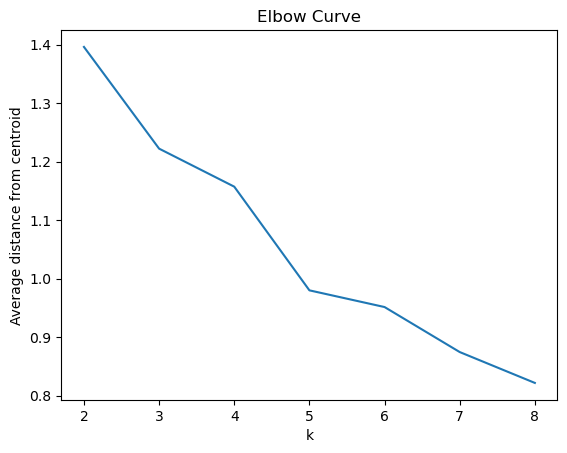

In [127]:
costs = []
for i in range(2 , 9):
    kmc = KMeansClustering(data)
    labels , centroids = kmc.solve(i)
    costs.append(kmc.eval(labels , centroids))
plt.plot(range(2, 9), costs)
plt.xlabel("k")
plt.ylabel("Average distance from centroid")
plt.title("Elbow Curve")
plt.show()

#### Since we observe elbow near 5(the rate of fall becomes significantly less after 5), we take k=5

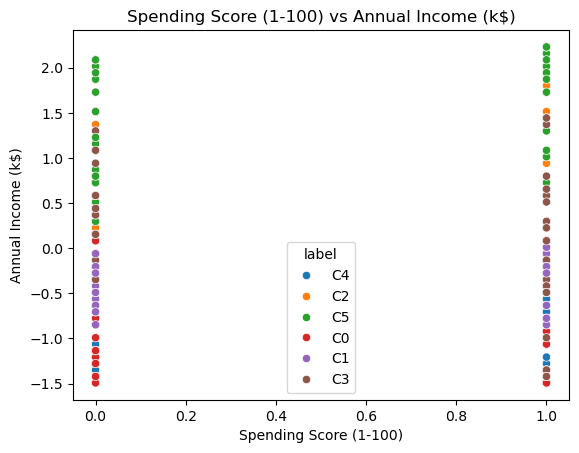

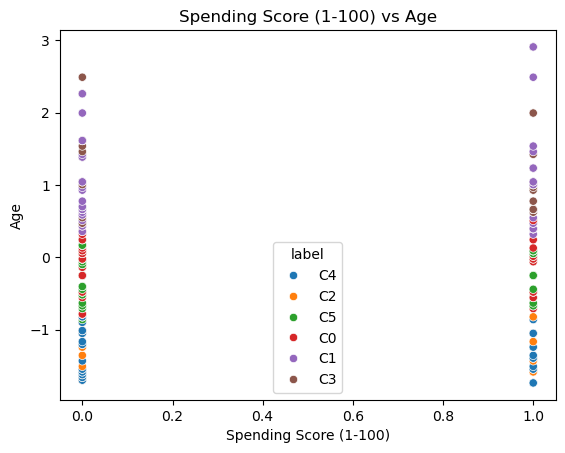

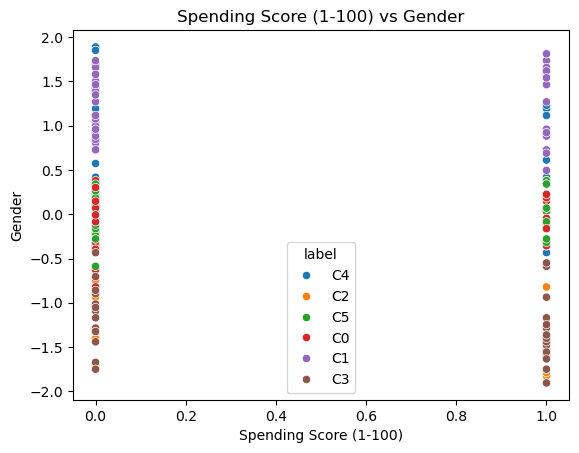

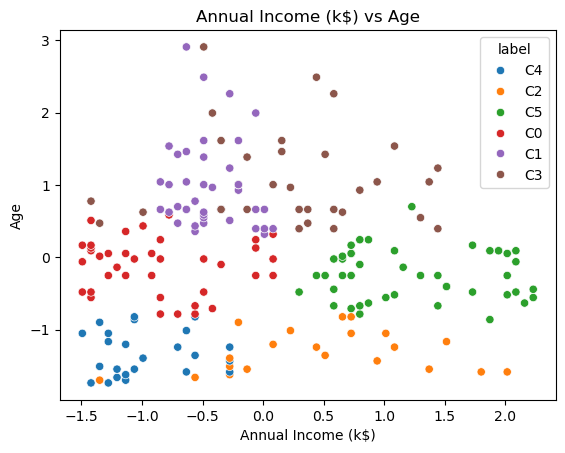

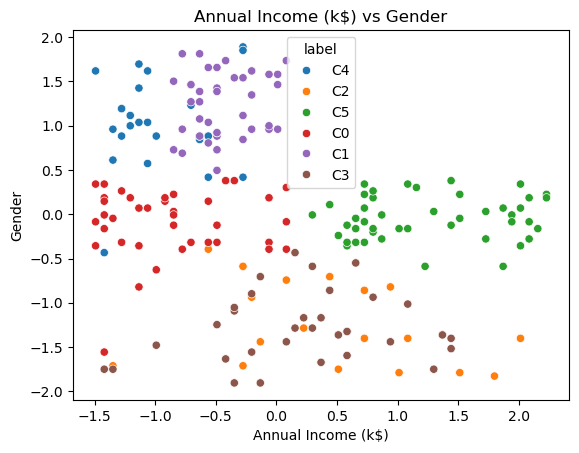

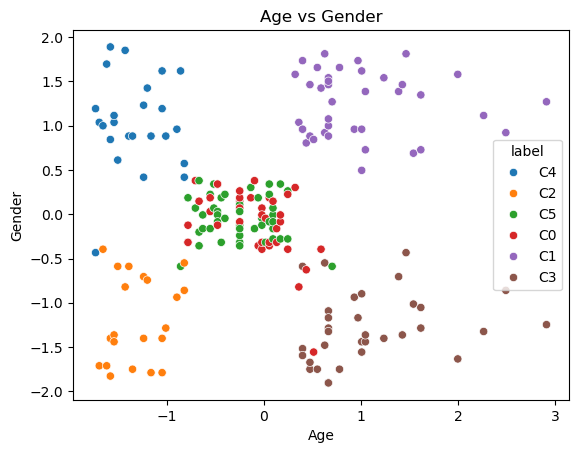

In [ ]:
kmc = KMeansClustering(data)
labels , centroids = kmc.solve(5)
kmc.plot(labels)

# Definfing K-Medoid Clustering

In [108]:
class KMedoidClustering: 
    def __init__(self , data):
        self.data = np.array(data)
        self.cols = data.columns

    def solve(self , k):
        label_medoid = {}
        labels = {}

        medoids = list(np.random.permutation(self.data)[:k])

        for i in range(k):
            label_medoid[tuple(medoids[i])] = f"C{i}"

        for idx, row in enumerate(self.data): 
            min_medoid = min(medoids , key = lambda x : np.sum(np.abs(x - row)))
            labels[idx] = label_medoid[tuple(min_medoid)] 

        max_iterations = 1000
        prev_cost = float('inf') 

        for _ in range(max_iterations):
            new_medoids = []

            for i in range(k):
                points = [self.data[j] for j in range(len(self.data)) if labels[j] == f"C{i}"]
                if len(points) == 0: new_medoids.append(medoids[i])
                else:
                    point = points[np.random.randint(len(points))]
                    new_medoids.append(point)

            new_label_medoid = {}
            for i in range(k):
                new_label_medoid[tuple(new_medoids[i])] = f"C{i}"
            for idx, row in enumerate(self.data): 
                min_medoid = min(new_medoids , key = lambda x : np.sum(np.abs(x - row)))
                labels[idx] = new_label_medoid[tuple(min_medoid)]
            curr_cost = np.mean([
                np.sum(np.abs(self.data[i] - new_medoids[ord(labels[i][1]) - ord('0')]))
                for i in range(len(self.data))
            ])
            if curr_cost > prev_cost:
                break
            prev_cost = curr_cost
            medoids = new_medoids  

        return labels , medoids

    def eval(self , labels , medoids):
        return np.mean([
            np.sum(np.abs(self.data[i] - medoids[ord(labels[i][1]) - ord('0')]))
            for i in range(len(self.data))
        ])

    def plot(self , labels):
        data2 = pd.DataFrame(self.data , columns = self.cols)
        data2["label"] = [labels[i] for i in range(len(self.data))] 

        for i in range(len(self.cols)):
            for j in range(i+1 , len(self.cols)):
                plt.figure()
                sns.scatterplot(
                    data=data2,
                    x=self.cols[i],
                    y=self.cols[j],
                    hue="label"
                )
                plt.title(f"{self.cols[i]} vs {self.cols[j]}")
                plt.show()

# Finding Best K value using Elbow Plot

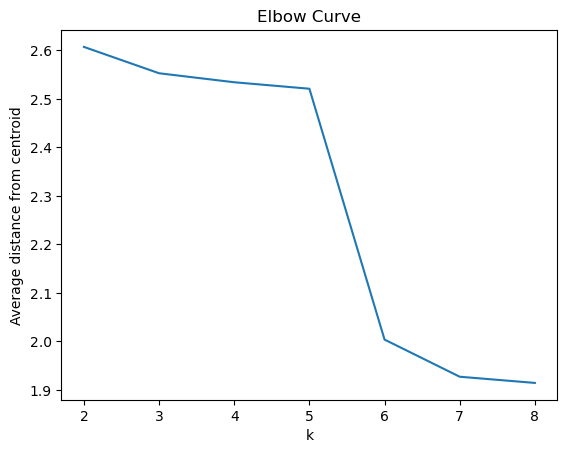

In [124]:
costs = []
for i in range(2 , 9):
    kmc = KMedoidClustering(data)
    labels , centroids = kmc.solve(i)
    costs.append(kmc.eval(labels , centroids))
plt.plot(range(2, 9), costs)
plt.xlabel("k")
plt.ylabel("Average distance from centroid")
plt.title("Elbow Curve")
plt.show()

### Since we observe elbow in the graph near 6 we take k = 6

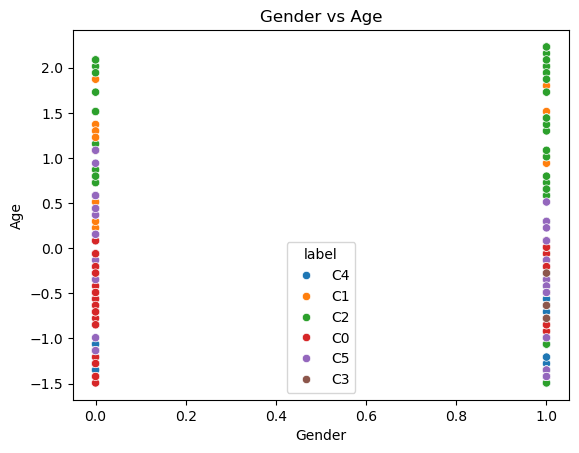

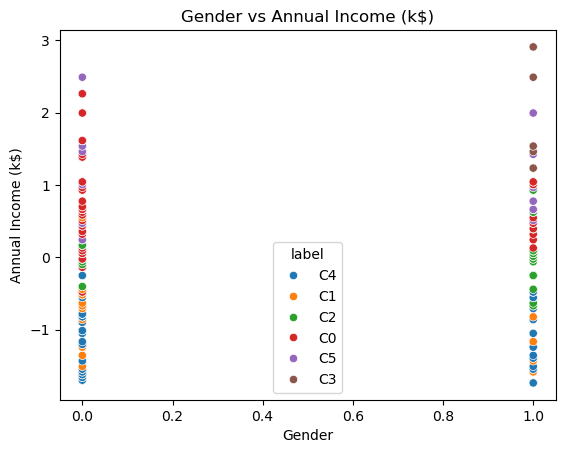

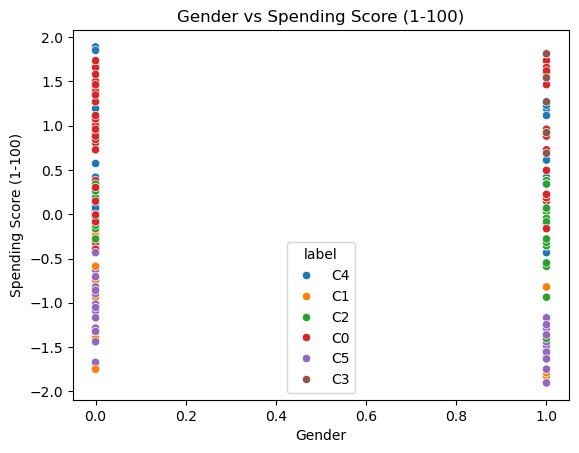

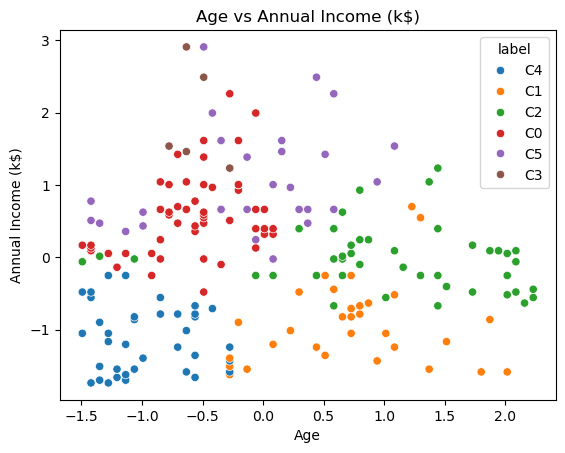

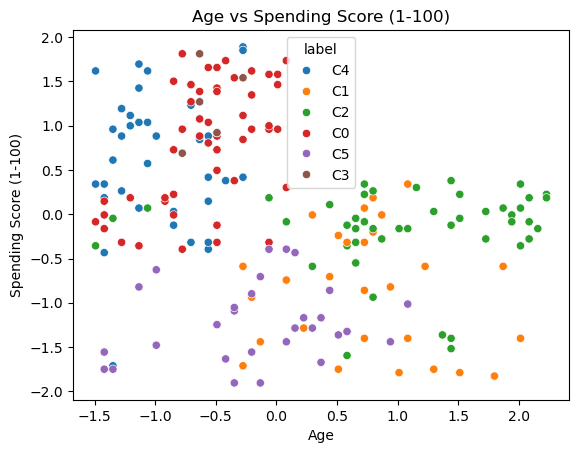

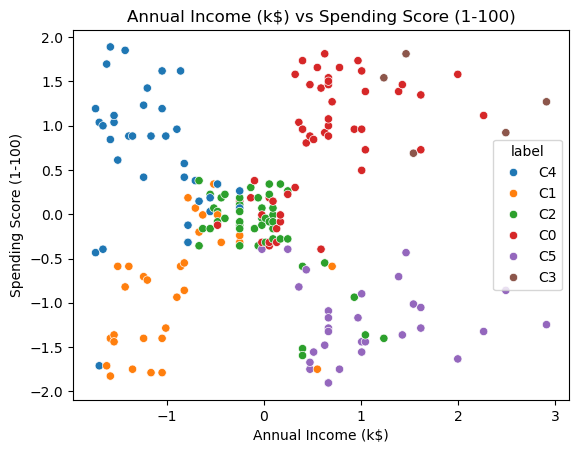

In [125]:
kmc = KMedoidClustering(data)
labels , centroids = kmc.solve(6)
kmc.plot(labels)